# Credit Card Fraud Detection Using Machine Learning

This project builds a machine learning model to detect fraudulent credit card transactions using real-world transaction data.

## 1. Introduction & Literature Review

Credit card fraud is a major problem in the financial industry, leading to large financial losses every year. With the rise of online transactions, detecting fraud has become more difficult using traditional rule-based systems. Machine learning offers a more efficient solution by automatically learning patterns from historical data.

In this project, we aim to build a machine learning model that classifies transactions as either normal (0) or fraudulent (1). This helps improve detection accuracy and reduces financial risk.

Fraud detection is challenging mainly because of class imbalance, where fraudulent transactions are extremely rare compared to normal ones. This imbalance can bias machine learning models toward predicting the majority class.

Researchers have used models such as Logistic Regression, Decision Trees, Random Forests, and Neural Networks for fraud detection. Ensemble methods like Random Forest often perform better due to their ability to reduce overfitting.

According to studies on the Kaggle Credit Card Fraud dataset, evaluation metrics like precision and recall are more important than accuracy because missing a fraud case (false negative) is more costly than a false alarm.

References:
- Dal Pozzolo et al., 2015, IEEE Symposium on Computational Intelligence
- Kaggle Dataset: Credit Card Fraud Detection (https://www.kaggle.com/mlg-ulb/creditcardfraud)

## 2. Problem Definition

The goal of this project is to detect fraudulent credit card transactions.

- Input: Transaction features (V1–V28, Amount, Time)
- Output: Class label (0 = Normal, 1 = Fraud)
- Problem Type: Binary Classification

We aim to build a model that correctly identifies fraudulent transactions while minimizing false negatives.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


Checking dataset shape, fraud distribution, and creates a smaller balanced dataset to make training easier.

In [3]:
# Check dataset size and class distribution

print("Dataset shape:", df.shape)
print(df['Class'].value_counts())

Dataset shape: (15936, 31)
Class
0.0    15862
1.0       73
Name: count, dtype: int64


Creates a smaller balanced dataset:

all fraud cases
same number of normal cases

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop rows with NaN values in the 'Class' column
df.dropna(subset=['Class'], inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

# split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# combine training data for balancing
train_data = pd.concat([X_train, y_train], axis=1)

fraud = train_data[train_data['Class'] == 1]
normal = train_data[train_data['Class'] == 0]

normal_sample = normal.sample(n=len(fraud), random_state=42)

balanced_train = pd.concat([fraud, normal_sample])

balanced_train = balanced_train.sample(frac=1, random_state=42)

X_train = balanced_train.drop('Class', axis=1)
y_train = balanced_train['Class']

# scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Preprocessing complete")

Preprocessing complete


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(kernel="rbf")
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    report = classification_report(y_test, preds, output_dict=True)

    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": report["1.0"]["precision"],
        "Recall": report["1.0"]["recall"],
        "F1-score": report["1.0"]["f1-score"]
    }

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.985253,0.203704,0.733333,0.318841
KNN,0.996548,0.611111,0.733333,0.666667
Decision Tree,0.963288,0.101562,0.866667,0.181818
Random Forest,0.994038,0.428571,0.800000,0.558140
SVM,0.978663,0.146667,0.733333,0.244444


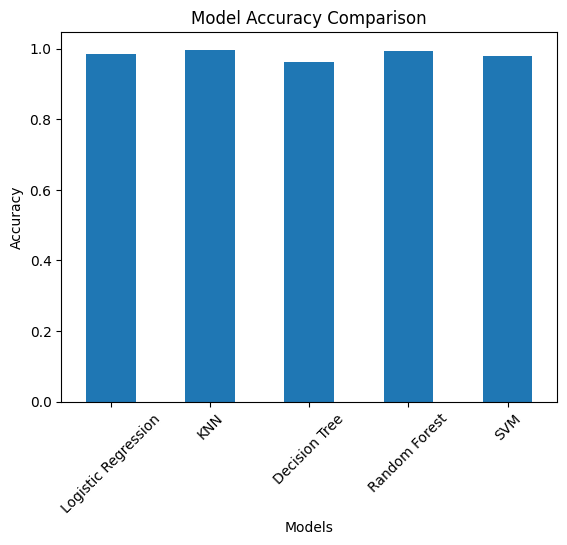

In [12]:
results_df["Accuracy"].plot(kind='bar')
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

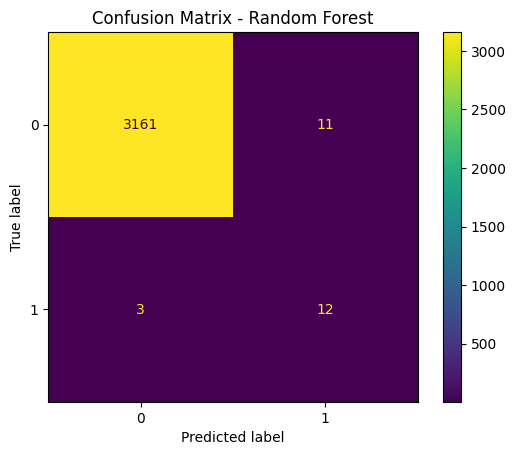

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [26]:
import numpy as np

# picking a transaction
sample_index = 4

sample = X_test[sample_index].reshape(1, -1)

prediction = best_model.predict(sample)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print( "Fraud Transaction Detected")
else:
    print("✅ Normal Transaction")

Prediction: 0.0
✅ Normal Transaction


## 6. Conclusion

In this project, we built a machine learning system to detect credit card fraud using multiple classification models.

We found that Random Forest performed best in identifying fraudulent transactions.

We learned the importance of handling imbalanced data and using evaluation metrics beyond accuracy.

Future work can improve performance using advanced sampling techniques or deep learning models.